In [2]:
import scanpy as sc
import anndata as ad
import numpy as np
import torch
import os
import plotly.express as px
import pandas as pd
from pathlib import Path
import sys
repo_root = Path('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_codes/STFateFlow')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from core.preprocessing import ae_dim_reduction

spatial_key = 'spatial_3d'

In [2]:
data_dir = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d'
# data_list = ['0hpa1', '0hpa2', '12hpa1', '12hpa2', '36hpa1', '36hpa2', '3dpa1', '3dpa2',
            #   '5dpa1', '5dpa2', '7dpa1', '7dpa2', '10dpa1', '10dpa2', '14dpa1', '14dpa2']
            
data_list = ['0hpa1', '12hpa1', '36hpa1', '3dpa1',
              '5dpa1', '7dpa1', '10dpa1', '14dpa1']

adata_list = []
time = 0

import numpy as np

out_key = "spatial_3d_unit"

for data_name in data_list:
    data_path = os.path.join(data_dir, data_name + '.spc.h5ad')
    adata = sc.read_h5ad(data_path)
    adata.obs['time_str'] = data_name
    adata.obsm[spatial_key] = adata.obsm[spatial_key] - adata.obsm[spatial_key].mean(axis=0)  # 中心化坐标
    coords = np.asarray(adata.obsm[spatial_key], dtype=np.float64)
    coord_min = coords.min(axis=0, keepdims=True)
    coord_max = coords.max(axis=0, keepdims=True)
    center = (coord_min + coord_max) / 2.0
    scale = np.max(coord_max - coord_min)  # 一个 scalar，不是每个轴一个 scale
    coords_unit = (coords - center) / scale + 0.5
    adata.obsm[out_key] = coords_unit.astype(np.float32)
    adata.obs['time'] = time
    time += 1
    adata_list.append(adata)
    
adata = ad.concat(adata_list, axis=0)

In [3]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

# Filter the counts.
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=adata.obs["n_genes_by_counts"].quantile(0.999))
sc.pp.filter_genes(adata, min_cells=3)
print("Filtered counts")

# Compute Pearson Residuals.
sc.pp.normalize_total(adata, target_sum=1e4) # 标准化每个细胞的总计数为 10,000
sc.pp.log1p(adata)                           # 计算 log1p(x) = log(x + 1)

sc.experimental.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    batch_key="time_str",
    subset=True,
    chunksize=500,
)
# sc.experimental.pp.normalize_pearson_residuals(adata)
# print("Computed Pearson Residuals")

Filtered counts


/data/yuz/tmp/ipykernel_1137790/3250926209.py:13: UserWarning: `flavor='pearson_residuals'` expects raw count data, but non-integers were found.
  sc.experimental.pp.highly_variable_genes(


In [4]:
adata.write_h5ad('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d/prista4d_spatial_unit.h5ad')

In [60]:
ae_model_save_path = '/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d/ae_prista4d.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
learning_rate = 1e-3
n_epochs = 1000
batch_size = 1000
early_stop = 30
valid_ratio = 0.1
seed = 19491001
ae_dim_reduction(adata, ae_model_save_path, gene_expression_key='spatial_3d', z_dims=10, device=device, 
                 learning_rate=learning_rate, n_epochs=n_epochs, batch_size=batch_size, 
                 early_stop=early_stop, valid_ratio=valid_ratio, seed=seed)

Start training autoencoder...
**Epoch 0**  
Train Loss: `0.189778`  
Valid Loss: `0.092860`
**Epoch 100**  
Train Loss: `0.056637`  
Valid Loss: `0.056648`
**Epoch 200**  
Train Loss: `0.054143`  
Valid Loss: `0.054312`
**Epoch 300**  
Train Loss: `0.052824`  
Valid Loss: `0.053046`
**Epoch 400**  
Train Loss: `0.052609`  
Valid Loss: `0.052824`
**Epoch 500**  
Train Loss: `0.052394`  
Valid Loss: `0.052600`
**Epoch 600**  
Train Loss: `0.052291`  
Valid Loss: `0.052535`
**Epoch 700**  
Train Loss: `0.052257`  
Valid Loss: `0.052494`
Early stopping in current iteration!
Autoencoder training finished.


In [6]:
time_str = '5dpa1'
y_coords = adata[adata.obs['time_str'] == time_str].obsm['spatial_3d_unit'][:, 0]
x_coords = adata[adata.obs['time_str'] == time_str].obsm['spatial_3d_unit'][:, 1]
z_coords = adata[adata.obs['time_str'] == time_str].obsm['spatial_3d_unit'][:, 2]
df = pd.DataFrame({
    'X': x_coords,
    'Y': y_coords,
    'Z': z_coords,
    'Annotation': adata[adata.obs['time_str'] == time_str].obs['anno'].astype(str) # 确保是分类变量字符串
})

# 3. 创建 3D 散点图
fig = px.scatter_3d(
    df, 
    x='X', 
    y='Y', 
    z='Z',
    color='Annotation',         # 按照 anno 字段着色
    title='3D Spatial Transcriptomics Visualization',
    opacity=0.8                 # 透明度，有助于观察重叠点
)

# 4. 调整点的大小和去除背景网格（可选，为了更好看）
fig.update_traces(marker=dict(size=3)) 
fig.update_layout(
    scene=dict(
        xaxis=dict(showbackground=False),
        yaxis=dict(showbackground=False),
        zaxis=dict(showbackground=False),
        aspectmode='data'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

# 5. 显示图像
fig.show()

In [6]:
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

'false'

In [7]:
# Cell 36: 准备参数与公共组件 + 计算并保存 FGWOT pi（不使用 wandb）
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
data_name = "prista4d"
fgw_alpha = 0.5
seed = 42

# New option: whether to normalize OT plan mass to 1.
# True keeps previous behavior.
ot_plan_normalize = False

from pathlib import Path
import numpy as np
from moscot.problems.spatiotemporal import SpatioTemporalProblem

# 5) FGWOT pi 缓存路径（本单元只写入，不读取）
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
pi_cache_path = pi_cache_dir / f"fgwot_pi_{data_name}_alpha{fgw_alpha}_gene_triu.npz"

# 6) 计算每个相邻时间段 FGWOT 的 pi 并保存
print("Computing FGWOT pi and writing cache...")
adata_for_fgw = adata
spatial_key = "spatial_3d"
# adata_for_fgw.obsm['X_ae'] = adata_for_fgw.obsm['X_ae'] / adata_for_fgw.obsm['X_ae'].max()

time_series = adata_for_fgw.obs["time"]
time_values = sorted(np.unique(time_series.to_numpy()).tolist())

problem = SpatioTemporalProblem(adata_for_fgw)

problem = problem.prepare(
    time_key="time",
    spatial_key=spatial_key,
    policy="triu",
    joint_attr={"attr": "X"},   # 关键：直接用 adata.X，不做默认 PCA
    cost={
        "xy": "sq_euclidean",   # gene expression term
        "x": "sq_euclidean",    # source spatial structure
        "y": "sq_euclidean",    # target spatial structure
    },
)
problem = problem.solve(alpha=float(fgw_alpha), epsilon=0, rank=200, tau_a = 0.97, tau_b = 0.93)

pi_by_transition = {}
cache_payload = {}
for i in range(len(time_values) - 1):
    for j in range(i + 1, i + 3):
        if j >= len(time_values):
            continue
        timea = time_values[i]
        timeb = time_values[j]
        if (timea, timeb) not in problem.solutions:
            print(f"Warning: No solution for transition {timea}->{timeb}. Skipping.")
            continue
        pi = np.asarray(problem.solutions[(timea, timeb)].transport_matrix, dtype=np.float64)
        pi = np.clip(pi, a_min=0.0, a_max=None)
        mass = float(pi.sum())
        if mass <= 0:
            raise ValueError(f"Invalid pi mass for transition {timea}->{timeb}")
        if ot_plan_normalize:
            pi = pi / mass
        pi_by_transition[(timea, timeb)] = pi
        cache_payload[f"transition_{timea}_{timeb}"] = pi
        print(f"transition {timea}->{timeb}, pi shape={pi.shape}, total mass={float(pi.sum()):.6f}")

np.savez_compressed(pi_cache_path, **cache_payload)
print(f"Saved FGWOT pi cache to: {pi_cache_path}")
# del adata_for_fgw

# 7) 统一 run_id（用于 checkpoint 路径，不依赖 wandb）
run_id = f"notebook_seed{seed}"

print("seed:", seed)
print("run_id:", run_id)
print("data_name:", data_name)
print("fgw_alpha:", fgw_alpha)
print("ot_plan_normalize:", ot_plan_normalize)
print("precomputed transitions:", sorted(pi_by_transition.keys()))
print("pi_cache_path:", pi_cache_path)
print("WandB disabled in this notebook pipeline.")

Computing FGWOT pi and writing cache...
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
WARNING  Densifying data in `adata.X`                                                                              
WARNING  Densifying data in `adata.X`                                                                              
INFO     Normalizing spatial coordinates of `x`.                                                                   
INFO     Normalizing spatial coordinates of `y`.                                                                   
WARNING  Densifying data in `adata.X`                                                                              
WARNING  Densifying data in `adata.X`                                                                              
INFO     Normalizing spatial coo

In [4]:
# Cell 37: 读取 FGWOT pi 缓存并构建 ot_sampler
import importlib
import core.utils.fgwot as fgwot_mod
import numpy as np

ot_plan_normalize = False
dataset_name = "prista4d" #mosta_subset_unaffine
fgw_alpha = 0.5

fgwot_mod = importlib.reload(fgwot_mod)
FGWOTPlanSampler = fgwot_mod.FGWOTPlanSampler

# New option: whether to normalize OT plan after loading.
# If cell 36 already set this value, reuse it.
ot_plan_normalize = bool(globals().get('ot_plan_normalize', True))
working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
# Keep cache feature space consistent with this notebook pipeline (X_ae).
pi_cache_path = pi_cache_dir / f"fgwot_pi_{dataset_name}_alpha{fgw_alpha}_gene_triu.npz"
pi_by_transition = {}
if pi_cache_path.exists():
    print(f"Loading precomputed FGWOT pi from: {pi_cache_path}")
    cached = np.load(pi_cache_path, allow_pickle=False)
    transition_keys = []
    for key in cached.files:
        if key.startswith("transition_"):
            timea = float(key.split("_")[1])
            timeb = float(key.split("_")[2])
            transition_keys.append((timea, timeb))
            pi = np.asarray(cached[key], dtype=np.float64)
            pi = np.clip(pi, a_min=0.0, a_max=None)
            mass = float(pi.sum())
            if mass <= 0:
                raise ValueError(f"Invalid cached pi mass for transition {timea}->{timeb}")
            if ot_plan_normalize:
                pi = pi / mass
            pi_by_transition[(timea, timeb)] = pi
    if not transition_keys:
        raise ValueError(f"No transition_* arrays found in cache: {pi_cache_path}")
    print("Loaded transitions:", sorted(transition_keys))
else:
    raise FileNotFoundError(f"FGWOT cache not found: {pi_cache_path}")

print("transitions:", sorted(pi_by_transition.keys()))
print("ot_plan_normalize:", ot_plan_normalize)


Loading precomputed FGWOT pi from: /data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis/fgwot_pi_prista4d_alpha0.5_gene_triu.npz
Loaded transitions: [(0.0, 1.0), (0.0, 2.0), (1.0, 2.0), (1.0, 3.0), (2.0, 3.0), (2.0, 4.0), (3.0, 4.0), (3.0, 5.0), (4.0, 5.0), (4.0, 6.0), (5.0, 6.0), (5.0, 7.0), (6.0, 7.0)]


NameError: name 'ot_sampler' is not defined

In [5]:
time_t = {
    "0hpa1": 0.0,
    "12hpa1": 0.4,
    "36hpa1": 1.1,
    "3dpa1": 2.1,
    "5dpa1": 3.6,
    "7dpa1": 5.0,
    "10dpa1": 7.1,
    "14dpa1": 10.0,
}

data_list = [
    "0hpa1", "12hpa1", "36hpa1", "3dpa1",
    "5dpa1", "7dpa1", "10dpa1", "14dpa1",
]

# 原始 index -> 新的 time 值
idx_to_time = {
    float(i): time_t[name]
    for i, name in enumerate(data_list)
}

pi_by_transition_new = {
    (idx_to_time[float(t0)], idx_to_time[float(t1)]): pi
    for (t0, t1), pi in pi_by_transition.items()
}

In [10]:
cache_payload = {
    f"transition_{t0}_{t1}": pi
    for (t0, t1), pi in pi_by_transition_new.items()
}

working_dir =  "/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/ot_pis"
pi_cache_dir = Path(working_dir)
pi_cache_dir.mkdir(parents=True, exist_ok=True)
# Keep cache feature space consistent with this notebook pipeline (X_ae).
pi_cache_path = pi_cache_dir / f"fgwot_pi_{dataset_name}_alpha{fgw_alpha}_gene_triu.npz"

np.savez_compressed(pi_cache_path, **cache_payload)

In [7]:
adata = sc.read_h5ad('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d/prista4d_spatial_unit.h5ad')

time_t = {
    "0hpa1": 0.0,
    "12hpa1": 0.4,
    "36hpa1": 1.1,
    "3dpa1": 2.1,
    "5dpa1": 3.6,
    "7dpa1": 5.0,
    "10dpa1": 7.1,
    "14dpa1": 10.0,
}

adata.obs["time"] = adata.obs["time_str"].map(time_t).astype(float)

# 可选：检查有没有没映射上的值
if adata.obs["time"].isna().any():
    missing = adata.obs.loc[adata.obs["time"].isna(), "time_str"].unique()
    raise ValueError(f"Unmapped time_str values: {missing}")

In [9]:
adata.write_h5ad('/data/yuz/spatialtranscriptomics/spatiotemporal/spatiotemporal_data/prista4d/prista4d_spatial_unit.h5ad')

2026-07-18 20:27:07.589 (   3.338s) [    789A8E5C6740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


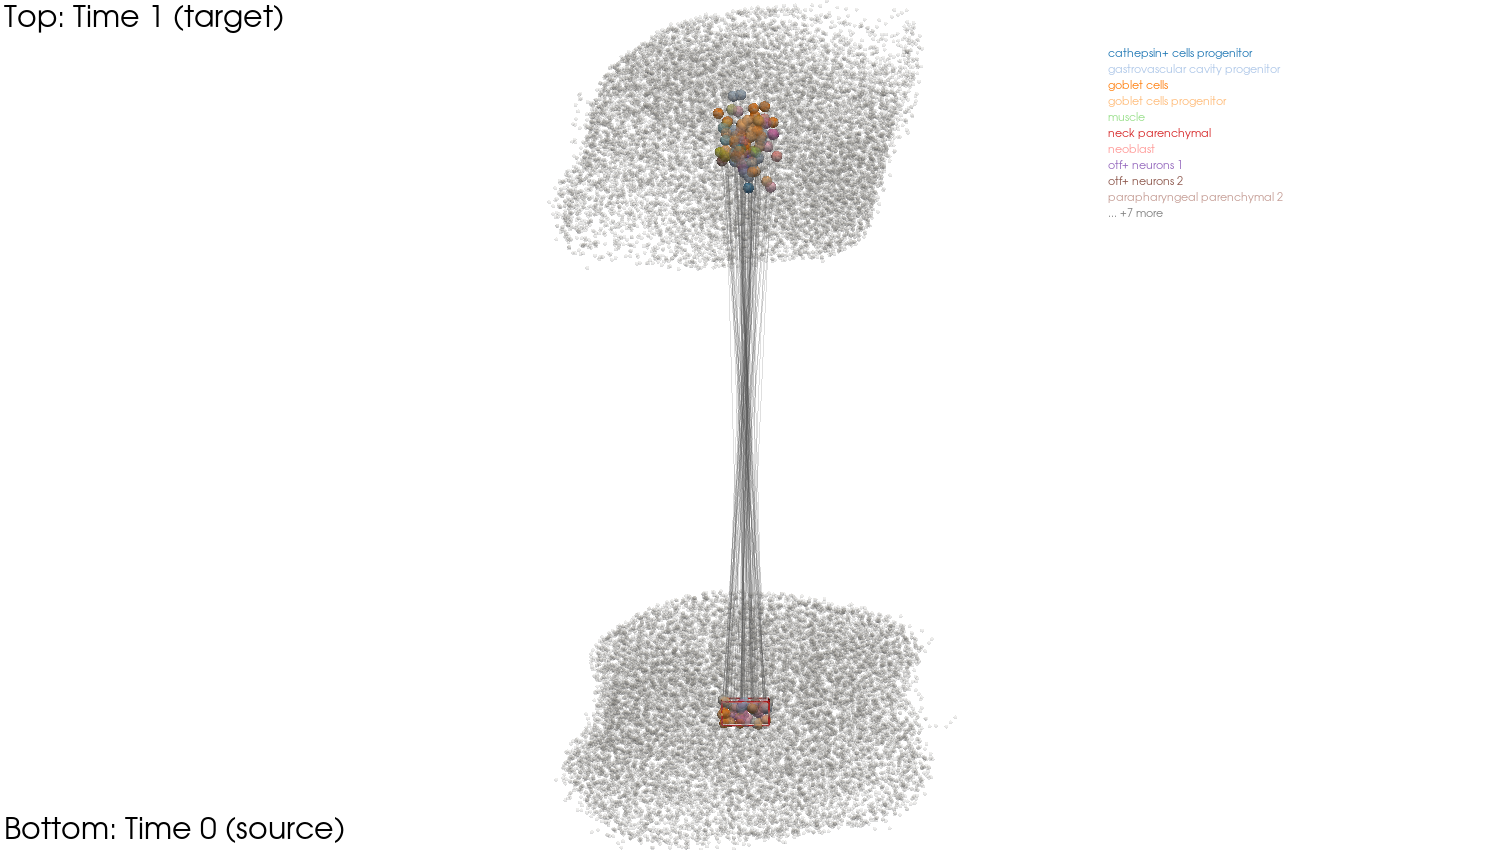

selected cube: x in [-100, 100], y in [-50, 50], z in [-50, 50]
matched transition key: (0, 1), transposed(original): False
sampling mode: sample_map-style global flatten on region block, seed=2026, replace=True
cell type key: anno
max_lines: 120
drawn source cells (with replacement): 94
unique sampled source cells in t=0: 58
unique sampled cells in t=1: 88
cell types in aligned pairs: 17
top cloud y-offset for vertical view: 2437.360
left margin shift (for legend clearance): -588.000
initial camera: view_xy


In [8]:
# 指定局部区域对齐可视化（3D，PyVista，按细胞类型着色）
import numpy as np
import matplotlib

try:
    import pyvista as pv
except ImportError as e:
    raise ImportError("pyvista is required. Install with: pip install pyvista") from e

if "pi_by_transition" not in globals() or not isinstance(pi_by_transition, dict) or len(pi_by_transition) == 0:
    raise RuntimeError("未检测到 pi_by_transition。请先运行读取 FGWOT pi 缓存的单元。")

# 1) 取两个时间点数据
t_obs_key = "time"
times = np.asarray(adata.obs[t_obs_key]).astype(float)
mask10 = np.isclose(times, 0)
mask15 = np.isclose(times, 1)

S10_raw = np.asarray(adata.obsm["spatial_3d"][mask10], dtype=np.float64)
S15_raw = np.asarray(adata.obsm["spatial_3d"][mask15], dtype=np.float64)

if S10_raw.shape[1] < 3 or S15_raw.shape[1] < 3:
    raise ValueError(f"spatial_3d must have >=3 dims for 3D plot, got {S10_raw.shape[1]} and {S15_raw.shape[1]}")

# 仅使用前三个维度进行3D可视化
S10_all = S10_raw[:, :3]
S15_all = S15_raw[:, :3]

n10, n15 = S10_all.shape[0], S15_all.shape[0]
if n10 == 0 or n15 == 0:
    raise ValueError("No cells found at time=0 or time=1")

# 自动识别细胞类型列（优先使用常见命名）
obs_type_key = "anno"

def _get_types(mask, n):
    if obs_type_key is None:
        return np.array(["unknown"] * n, dtype=object)
    vals = np.asarray(adata.obs.loc[mask, obs_type_key]).astype(str)
    vals[vals == "nan"] = "unknown"
    return vals

types10_all = _get_types(mask10, n10)
types15_all = _get_types(mask15, n15)

# 2) 选取指定3D立方体区域
x_min, x_max = -100, 100
y_min, y_max = -50, 50
z_min, z_max = -50, 50

region_mask = (
    (S10_all[:, 0] >= x_min)
    & (S10_all[:, 0] <= x_max)
    & (S10_all[:, 1] >= y_min)
    & (S10_all[:, 1] <= y_max)
    & (S10_all[:, 2] >= z_min)
    & (S10_all[:, 2] <= z_max)
)
region_idx = np.where(region_mask)[0]
if region_idx.size == 0:
    raise ValueError(
        f"指定区域内没有细胞: x in [{x_min}, {x_max}], y in [{y_min}, {y_max}], z in [{z_min}, {z_max}]"
    )

# 可选: 限制连线数，避免图过密
max_lines = 120
if region_idx.size > max_lines:
    rng_sub = np.random.default_rng(42)
    region_idx = np.sort(rng_sub.choice(region_idx, size=max_lines, replace=False))

# 3) 自动匹配对应时间段的对齐矩阵
matched_key = None
P = None
transposed = False

for k in sorted(pi_by_transition.keys()):
    pi = np.asarray(pi_by_transition[k], dtype=np.float64)
    if pi.ndim != 2:
        continue
    if pi.shape == (n10, n15) or pi.shape == (n15, n10):
        matched_key = k
        P = pi
        transposed = False if pi.shape == (n10, n15) else True
        break

if P is None:
    raise ValueError(f"No transition matrix in pi_by_transition matches ({n10}, {n15}) or ({n15}, {n10})")

if transposed:
    P = P.T

# 4) sample_map 风格采样（在区域子矩阵上 flatten 采样）
P_nonneg = np.clip(P, a_min=0.0, a_max=None)
P_region = P_nonneg[region_idx, :]  # shape: (n_region, n15)

total_mass = float(P_region.sum())
if total_mass <= 1e-16:
    raise ValueError("Selected region has zero transport mass; cannot sample.")

p_flat = (P_region / total_mass).reshape(-1)
sample_seed = 2026
rng = np.random.default_rng(sample_seed)

choices = rng.choice(
    P_region.shape[0] * P_region.shape[1],
    size=region_idx.size,
    replace=True,
    p=p_flat,
)
row_local, aligned_idx = np.divmod(choices, P_region.shape[1])

source_idx = region_idx[row_local]
S10_region = S10_all[source_idx]
S15_aligned = S15_all[aligned_idx]

# 当前对齐对的细胞类型（左右各自按对应时间点类型着色）
type_src = types10_all[source_idx]
type_tgt = types15_all[aligned_idx]
types_union = np.unique(np.concatenate([type_src, type_tgt]))
n_types = int(types_union.size)

if n_types <= 20:
    cmap = matplotlib.colormaps.get_cmap("tab20").resampled(max(n_types, 1))
else:
    cmap = matplotlib.colormaps.get_cmap("gist_ncar").resampled(n_types)

type_to_color = {t: cmap(i) for i, t in enumerate(types_union)}

# 准备 RGB 颜色
src_rgb = (np.asarray([type_to_color[t][:3] for t in type_src]) * 255).astype(np.uint8)
tgt_rgb = (np.asarray([type_to_color[t][:3] for t in type_tgt]) * 255).astype(np.uint8)

# 5) PyVista 可视化
# 改为上下布局：将 time=1 点云沿 y 轴整体上移，在同一场景内直接连线
x_span_ref = max(float(np.ptp(S10_all[:, 0])), float(np.ptp(S15_all[:, 0])), 1.0)
y_span_ref = max(float(np.ptp(S10_all[:, 1])), float(np.ptp(S15_all[:, 1])), 1.0)

bottom_max_y = float(np.max(S10_all[:, 1]))
top_min_y = float(np.min(S15_all[:, 1]))
offset_y = (bottom_max_y - top_min_y) + 1.2 * y_span_ref

S15_all_plot = S15_all.copy()
S15_all_plot[:, 1] += offset_y
S15_aligned_plot = S15_aligned.copy()
S15_aligned_plot[:, 1] += offset_y

# 为了给图例留空白，整体略向左平移
left_margin_shift = -0.35 * x_span_ref
S10_all_plot = S10_all.copy()
S10_all_plot[:, 0] += left_margin_shift
S10_region_plot = S10_region.copy()
S10_region_plot[:, 0] += left_margin_shift
S15_all_plot[:, 0] += left_margin_shift
S15_aligned_plot[:, 0] += left_margin_shift

# 选中区域立方体（随左侧点云一起平移）
cube_center = (
    (x_min + x_max) / 2.0 + left_margin_shift,
    (y_min + y_max) / 2.0,
    (z_min + z_max) / 2.0,
)
cube = pv.Cube(center=cube_center, x_length=(x_max - x_min), y_length=(y_max - y_min), z_length=(z_max - z_min))

# 若 notebook 环境可用，优先静态后端以减少依赖问题
try:
    pv.set_jupyter_backend("static")
except Exception:
    pass

plotter = pv.Plotter(window_size=(1500, 850))
plotter.set_background("white")

# 下方：time 0
bottom_other = pv.PolyData(S10_all_plot)
plotter.add_mesh(bottom_other, color="#c8c8c8", point_size=4, render_points_as_spheres=True, opacity=0.20)

bottom_sel = pv.PolyData(S10_region_plot)
bottom_sel["rgb"] = src_rgb
plotter.add_mesh(bottom_sel, scalars="rgb", rgb=True, point_size=10, render_points_as_spheres=True, opacity=0.95)
plotter.add_mesh(cube, style="wireframe", color="#d62728", line_width=2)

# 上方：time 1（上移后）
top_other = pv.PolyData(S15_all_plot)
plotter.add_mesh(top_other, color="#c8c8c8", point_size=4, render_points_as_spheres=True, opacity=0.20)

top_sel = pv.PolyData(S15_aligned_plot)
top_sel["rgb"] = tgt_rgb
plotter.add_mesh(top_sel, scalars="rgb", rgb=True, point_size=11, render_points_as_spheres=True, opacity=0.95)

# 上下对齐连线
for i in range(S10_region_plot.shape[0]):
    line = pv.Line(S10_region_plot[i], S15_aligned_plot[i])
    plotter.add_mesh(line, color="#4f4f4f", line_width=1, opacity=0.18)

# 用屏幕叠加文字标注，避免遮挡3D主体
plotter.add_text("Top: Time 1 (target)", position="upper_left", font_size=12, color="black")
plotter.add_text("Bottom: Time 0 (source)", position="lower_left", font_size=12, color="black")

# 简化版图例：缩小并放右上角（通常为空白区），减少遮挡
legend_limit = 10
types_for_legend = sorted(types_union.tolist())
if len(types_for_legend) > legend_limit:
    shown_types = types_for_legend[:legend_limit]
    hidden_n = len(types_for_legend) - legend_limit
else:
    shown_types = types_for_legend
    hidden_n = 0

legend_entries = [(t, type_to_color[t][:3]) for t in shown_types]
if hidden_n > 0:
    legend_entries.append((f"... +{hidden_n} more", "gray"))
plotter.add_legend(legend_entries, bcolor="white", border=True, size=(0.13, 0.22), loc="upper right")

# 去掉坐标轴与网格（并确保无方向轴）
plotter.hide_axes()

# 设定初始相机为 XY 视角，使“上下布局”在首帧更直观
plotter.view_xy()
plotter.camera.zoom(1.15)

plotter.show()

print(f"selected cube: x in [{x_min}, {x_max}], y in [{y_min}, {y_max}], z in [{z_min}, {z_max}]")
print(f"matched transition key: {matched_key}, transposed(original): {transposed}")
print(f"sampling mode: sample_map-style global flatten on region block, seed={sample_seed}, replace=True")
print(f"cell type key: {obs_type_key if obs_type_key is not None else 'None (fallback=unknown)'}")
print(f"max_lines: {max_lines}")
print(f"drawn source cells (with replacement): {S10_region_plot.shape[0]}")
print(f"unique sampled source cells in t=0: {np.unique(source_idx).size}")
print(f"unique sampled cells in t=1: {np.unique(aligned_idx).size}")
print(f"cell types in aligned pairs: {n_types}")
print(f"top cloud y-offset for vertical view: {offset_y:.3f}")
print(f"left margin shift (for legend clearance): {left_margin_shift:.3f}")
print("initial camera: view_xy")